In [44]:
# Wisconsin Breast Cancer Data Set
# 암세포의 특징 10개에 대해서
# 평균, 표준편차, 최대이상치에 대한 데이터 셋

# 필요한 module import
from sklearn.datasets import load_breast_cancer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from sklearn import linear_model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Recall, Precision

from sklearn.model_selection import cross_val_score

In [ ]:
# 1. Raw Data Loading
cancer =load_breast_cancer()
# print(type(cancer))  # <class 'sklearn.utils._bunch.Bunch'>
# Bunch 클래스는 sklearn에서 제공하는 class로 python의 dict와
# 유사하다고 생각하면 되요!

# data속성(key값)이 있는데 feature가 들어가 있어요!
# target속성(key값)이 있는데 label이 들어가 있어요!
# print(cancer.data.shape) # (569, 30)
# print(cancer.target.shape) # (569,)

# target안에 어떤값이 들어가 있는지 확인하고 싶어요!
# 데이터 불균형이 있는지 같이 확인하고 싶어요!
# print(np.unique(cancer.target, return_counts=True))
# (array([0, 1]), array([212, 357]))
# 약간의 불균형이 있기는 하지만 일단 그냥 넘어가요!

print(cancer.DESCR)
# class 0은 악성세포, class 1은 양성세포
# 여기에 나오는 각종 수치들(feature에 대한 수치들)
# 이게 어떤 의미인지 다 알아야 하나요?
# 머신러닝 모델을 구현하는 입장에서 이 수치들의 의미를
# 다 알필요는 없어요! => 알면 좋아요!
# 도메인 전문가가 있으면 좋아요!

In [37]:
# 데이터셋 저장
x_data = cancer.data     # 2차원 ndarray
t_data = cancer.target   # 1차원 ndarray

# 데이터 전처리
# DataFrame을 만들어서 처리하면 좋을거 같아요!
# 1. 결측치 처리(DESC에서 결측치는 없다고 했어요!)
x_data_df = pd.DataFrame(x_data)
# display(x_data_df.head())
t_data_df = pd.DataFrame(t_data.reshape(-1,1))
# display(t_data_df.head())
df = pd.concat([t_data_df, x_data_df], axis=1)
# display(df.head())
# 결측치가 있는지 확인해 보아요!
# df.columns[df.isnull().any(axis=0)]
# 결측치는 존재하지 않네요!
# 2. 이상치 처리
# 각 컬럼마다 이상치를 찾아서 제거해서 사용할꺼예요!
# 사실 데이터이기 때문에 이상치로 판별은 되지만
# 실제값이예요! 따라서 삭제하면 안되요!
# 나중에 한번 이상치 처리는 따로 해본 후
# 모델을 만들어서 모델의 정확도를 비교해보세요!
# 3. 정규화 처리
scaler = MinMaxScaler()
scaler.fit(x_data)
x_data_norm = scaler.transform(x_data)
# print(x_data_norm)
# 4. 데이터 분리
x_data_train_norm, x_data_test_norm, t_data_train, t_data_test = \
train_test_split(x_data_norm,
                 t_data,
                 test_size=0.2,
                 stratify=t_data,
                 random_state=2)
# 분리된 데이터의 class 비율이 유지되고 있는지 확인!
# print(np.unique(t_data_train, return_counts=True))

(array([0, 1]), array([170, 285]))


In [41]:
# Model 구현
sklearn_model = linear_model.LogisticRegression()
# sklearn_model.fit(x_data_train_norm,
#                   t_data_train)
# print(sklearn_model.score(x_data_test_norm,t_data_test))
# 0.96491

# 모델을 생성한 후 Cross Validation을 진행
score = cross_val_score(sklearn_model,
                        x_data_train_norm,
                        t_data_train,
                        cv=5)
print(score.mean())

0.9648351648351647


In [57]:
# Tensorflow 구현

keras_model = Sequential()

keras_model.add(Flatten(input_shape=(30,)))
keras_model.add(Dense(units=1,
                      activation='sigmoid'))
keras_model.compile(optimizer=Adam(learning_rate=1e-2),
                    loss='binary_crossentropy',
                    metrics=['accuracy'])

history = keras_model.fit(x_data_train_norm,
                          t_data_train.reshape(-1,1),
                          epochs=300,
                          verbose=0,
                          validation_split=0.2,
                          batch_size=100)

In [58]:
result = keras_model.evaluate(x_data_test_norm,
                              t_data_test.reshape(-1,1))
print(result) # [0.6121866106987, 0.8771929740905762]
# 첫번째 값은 loss값, 두번째 값이 accuracy값.

# learning_rate가 1e-2일때 결과 : [0.11009726673364639, 0.9649122953414917]

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9714 - loss: 0.1092
[0.11009726673364639, 0.9649122953414917]


<class 'keras.src.callbacks.history.History'>
{'accuracy': [0.6291208863258362, 0.6291208863258362, 0.6291208863258362, 0.6291208863258362, 0.6291208863258362, 0.6318681240081787, 0.6318681240081787, 0.6346153616905212, 0.6346153616905212, 0.6373626589775085, 0.6373626589775085, 0.6373626589775085, 0.6373626589775085, 0.6373626589775085, 0.6373626589775085, 0.6373626589775085, 0.6373626589775085, 0.6401098966598511, 0.6428571343421936, 0.6428571343421936, 0.6428571343421936, 0.6428571343421936, 0.6456043720245361, 0.651098906993866, 0.651098906993866, 0.6538461446762085, 0.656593382358551, 0.656593382358551, 0.656593382358551, 0.656593382358551, 0.656593382358551, 0.656593382358551, 0.656593382358551, 0.6620879173278809, 0.6620879173278809, 0.6620879173278809, 0.6620879173278809, 0.6675823926925659, 0.6675823926925659, 0.6675823926925659, 0.6675823926925659, 0.6703296899795532, 0.6730769276618958, 0.6730769276618958, 0.6730769276618958, 0.6730769276618958, 0.6758241653442383, 0.6758241

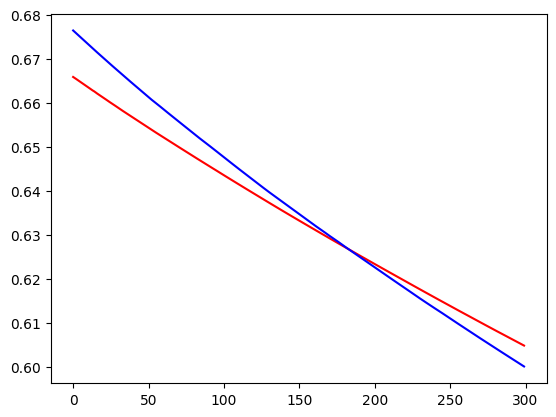

In [54]:
print(type(history))
# 우리가 원하는 loss와 accuracy에 대한 데이터는 history객체에 history속성에
# 포함되어 있어요!
print(history.history)

# plt.plot(history.history['accuracy'], color='r')
# plt.plot(history.history['val_accuracy'], color='b')

plt.plot(history.history['loss'], color='r')
plt.plot(history.history['val_loss'], color='b')

plt.show()

In [ ]:
# Logistic Regression 연습문제
# DataSet은 Kaggle에서 다운로드

# Kaggle이 제공해준 titanic data set을 이용해서
# Logistic Regression을 구현할 꺼예요!
# Tensorflow Keras로 구현할 꺼예요!